# **K Nearest Neighbors**

K Nearest Neighbors (KNN) adalah algoritma pembelajaran mesin yang digunakan untuk klasifikasi dan regresi. KNN bekerja dengan mencari K tetangga terdekat dari data yang ingin diprediksi, kemudian menggunakan informasi dari tetangga tersebut untuk membuat prediksi.


## **Import Libraries**


In [2]:
# Uncommeend jika belum mendownload librari yang dibutuhkan
# %pip install opencv-python
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn 
# %pip install scikit-image 
# %pip install scikit-learn

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog, graycomatrix, graycoprops
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## **Data Understanding**


In [4]:
DATASET_PATH = './data'
KATEGORI = ['Plastic', 'Paper', 'Metal', 'Glass', 'Biological']

In [5]:
all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
	for fname in files:
		if fname.lower().endswith(('.jpg')):
			all_files.append(os.path.join(root, fname))

print(f"Total file: {len(all_files)}")

Total file: 8720


In [6]:
jumlah_data = []
for kategori in KATEGORI:
  folder_path = os.path.join(DATASET_PATH, kategori)
  if os.path.exists(folder_path):
    jumlah = len(os.listdir(folder_path))
    jumlah_data.append(jumlah)
    print(f"Dataset {kategori}: {jumlah} gambar")
  else:
    jumlah_data.append(0)
    print(f"Peringatan: Folder {kategori} tidak ditemukan!")

Dataset Plastic: 1984 gambar
Dataset Paper: 1680 gambar
Dataset Metal: 1019 gambar
Dataset Glass: 3061 gambar
Dataset Biological: 997 gambar


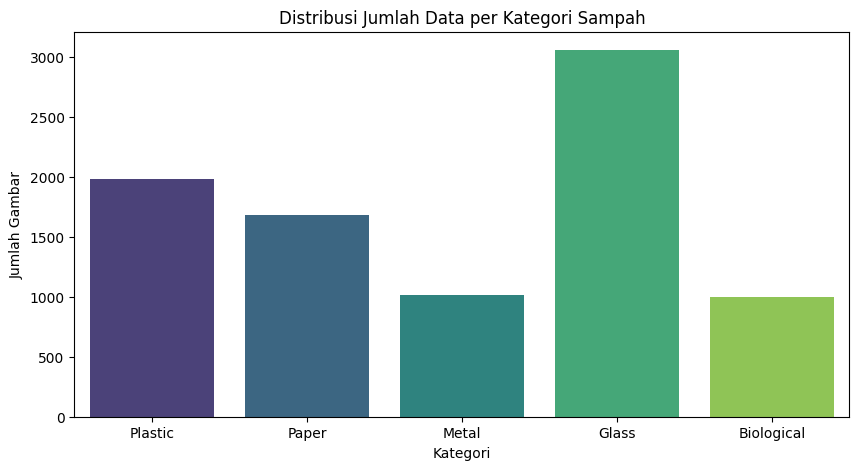

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(x=KATEGORI, y=jumlah_data, palette="viridis", hue=KATEGORI, legend=False)
plt.title("Distribusi Jumlah Data per Kategori Sampah")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Gambar")
plt.show();

## **Data Preparation**


In [32]:
def extract_features(image, return_visual=False):
  # Histogram RGB
  hist_r = cv2.calcHist([image], [0], None, [32], [0, 256]).flatten()
  hist_g = cv2.calcHist([image], [1], None, [32], [0, 256]).flatten()
  hist_b = cv2.calcHist([image], [2], None, [32], [0, 256]).flatten()
  
  # Histogram HSV
  hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  hist_h = cv2.calcHist([hsv_image], [0], None, [32], [0, 256]).flatten()
  hist_s = cv2.calcHist([hsv_image], [1], None, [32], [0, 256]).flatten()
  hist_v = cv2.calcHist([hsv_image], [2], None, [32], [0, 256]).flatten()
  
  color_features = np.concatenate([hist_r, hist_g, hist_b])
  
  # GLCM (Analisis Tekstur Spasial)
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  glcm = graycomatrix(gray_image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)
  
  contrast = graycoprops(glcm, 'contrast').flatten()
  correlation = graycoprops(glcm, 'correlation').flatten()
  energy = graycoprops(glcm, 'energy').flatten()
  homogeneity = graycoprops(glcm, 'homogeneity').flatten()
  
  # HOG (Bentuk)
  if return_visual:
    hog_features, hog_image = hog(gray_image, orientations=8, pixels_per_cell=(16, 16),
                                  cells_per_block=(1, 1), visualize=True)
    return np.concatenate([color_features, hog_features]), hist_r, hist_g, hist_b, hog_image
  else:
    hog_features = hog(gray_image, orientations=8, pixels_per_cell=(16, 16),
                        cells_per_block=(1, 1), visualize=False)
    return np.concatenate([hist_r, hist_g, hist_b, 
                          hist_h, hist_s, hist_v, 
                          contrast, correlation, energy, homogeneity, 
                          hog_features])

In [33]:
contoh_path = os.path.join(DATASET_PATH, KATEGORI[0], os.listdir(os.path.join(DATASET_PATH, KATEGORI[0]))[0])
contoh_img = cv2.imread(contoh_path)
contoh_img_resized = cv2.resize(contoh_img, (128, 128))
fitur_lengkap, hr, hg, hb, hog_vis = extract_features(contoh_img_resized, return_visual=True)

print(f"Total ukuran vektor fitur per gambar: {len(fitur_lengkap)} dimensi")

Total ukuran vektor fitur per gambar: 608 dimensi


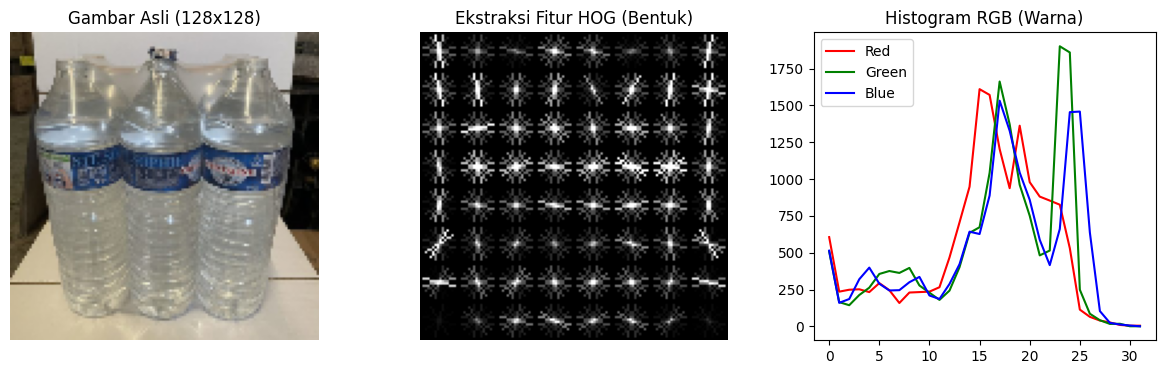

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.imshow(cv2.cvtColor(contoh_img_resized, cv2.COLOR_BGR2RGB))
ax1.set_title('Gambar Asli (128x128)')
ax1.axis('off')

hog_image_rescaled = exposure.rescale_intensity(hog_vis, in_range=(0, 10))
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Ekstraksi Fitur HOG (Bentuk)')
ax2.axis('off')

ax3.plot(hr, color='r', label='Red')
ax3.plot(hg, color='g', label='Green')
ax3.plot(hb, color='b', label='Blue')
ax3.set_title('Histogram RGB (Warna)')
ax3.legend()
plt.show()

## **Feature Extraction**


In [34]:
X = []
y = []

In [35]:
for label_idx, kategori in enumerate(KATEGORI):
  folder_path = os.path.join(DATASET_PATH, kategori)
  if not os.path.exists(folder_path): continue
  
  for filename in os.listdir(folder_path):
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path)
    if img is not None:
      img_resized = cv2.resize(img, (128, 128))
      fetures = extract_features(img_resized)
      X.append(fetures)
      y.append(label_idx)

In [36]:
X = np.array(X)
y = np.array(y)

In [37]:
# Data Splitting 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Proses Selesai! Data Training: {len(X_train)}, Data Testing: {len(X_test)}")

Proses Selesai! Data Training: 6992, Data Testing: 1749


## **Standard Scaler**

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [40]:
print(f"Dimensi setelah PCA: {X_train_pca.shape[1]} fitur utama (Jauh lebih ringan untuk KNN!)")

Dimensi setelah PCA: 438 fitur utama (Jauh lebih ringan untuk KNN!)


## **Modeling & Parameter Tuning**


In [57]:
k_range = range(1, 16)
train_scores = []
test_scores = []

In [58]:
for k in k_range:
	knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='distance')
	knn.fit(X_train, y_train)
	
	train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
	test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

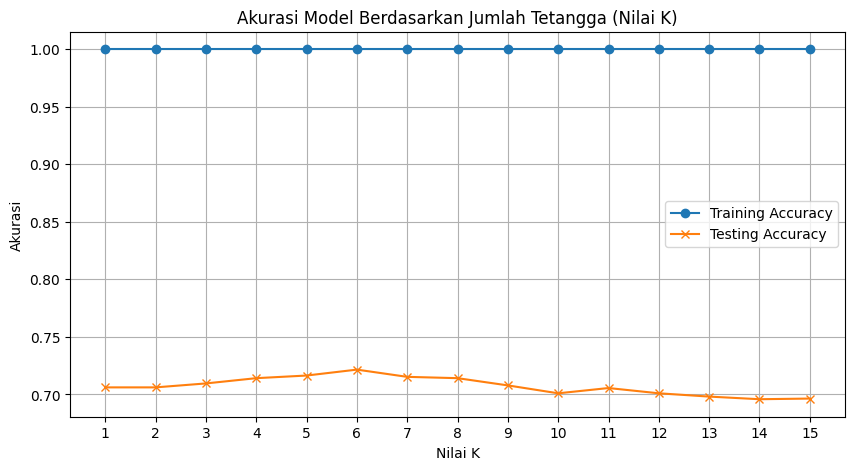

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, label='Training Accuracy', marker='o')
plt.plot(k_range, test_scores, label='Testing Accuracy', marker='x')
plt.title('Akurasi Model Berdasarkan Jumlah Tetangga (Nilai K)')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

In [60]:
best_k = k_range[np.argmax(test_scores)]
print(f"Nilai K paling optimal ditemukan pada: K = {best_k}")

Nilai K paling optimal ditemukan pada: K = 6


In [61]:
final_knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan', weights='distance')
final_knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## **Evaluation**


In [62]:
y_pred = final_knn_model.predict(X_test)

In [63]:
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Metrik Detail (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=KATEGORI))

Akurasi Keseluruhan: 72.16%

Laporan Metrik Detail (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

     Plastic       0.72      0.68      0.70       397
       Paper       0.71      0.85      0.77       336
       Metal       0.71      0.48      0.57       204
       Glass       0.76      0.77      0.77       612
  Biological       0.64      0.70      0.67       200

    accuracy                           0.72      1749
   macro avg       0.71      0.69      0.70      1749
weighted avg       0.72      0.72      0.72      1749



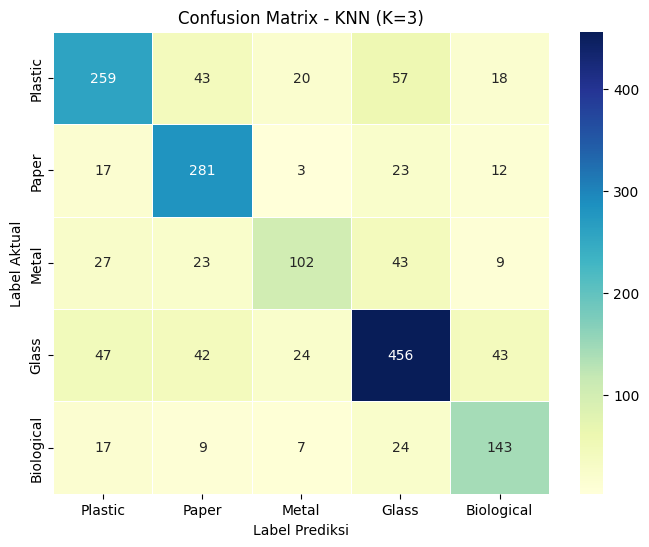

In [52]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=KATEGORI, yticklabels=KATEGORI, linewidths=.5)
plt.title(f'Confusion Matrix - KNN (K={best_k})')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()

## **Inference**


In [23]:
def predict_new_image(image_path, model):
	if not os.path.exists(image_path):
		print(f"File tidak ditemukan: {image_path}")
		return

	img = cv2.imread(image_path)
	if img is None:
		print("Format gambar salah atau korup.")
		return
			
	img_resized = cv2.resize(img, (128, 128))
	features = extract_features(img_resized)
	
	# Prediksi
	prediction = model.predict([features])
	confidence_scores = model.predict_proba([features])[0]
	predicted_class = KATEGORI[prediction[0]]
	confidence = max(confidence_scores) * 100
	
	# Plot hasil visual
	plt.figure(figsize=(5, 5))
	img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
	plt.imshow(img_rgb)
	plt.axis('off')
	plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}%)")
	plt.show()
	
	print(f"🤖 Hasil Analisis  : Kategori {predicted_class}")
	print(f"✅ Nilai Kepercayaan: {confidence:.2f}%")

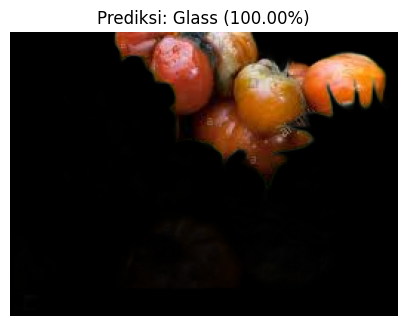

🤖 Hasil Analisis  : Kategori Glass
✅ Nilai Kepercayaan: 100.00%


In [29]:
predict_new_image('./data/biological/biological_100.jpg', final_knn_model)